Default case analysis

In [1]:
%run setup.py
mdates.set_epoch('2025-01-01')
from import_data import get_data


In [2]:
filenames = ['case1/no-behav.sqlite']

In [3]:
# list all unphysical commodities that should be ignored
ignore_commods = ['fluorine', 'oxygen', 'extra_fluorine', 'extra_oxygen', 'silica']

In [4]:
data = {}
for file in filenames:
    (name, file_data) = get_data(file, ignore_commods)
    
    print(name)
    
    data[name] = file_data

if len(data.keys()) == 1:
    data = data[list(data.keys())[0]]

case1


In [5]:
data.keys()

dict_keys(['db', 'ev', 'agents', 'facilities', 'transactions', 'ei', 'rx_events'])

In [6]:
data['transactions'].columns

Index(['SimId', 'ResourceId', 'ObjId', 'Type', 'TimeCreated', 'Quantity',
       'Units', 'QualId', 'PackageName', 'Parent1', 'Parent2', 'TransactionId',
       'SenderId', 'ReceiverId', 'Commodity', 'Time', 'SenderSpec',
       'SenderPrototype', 'ReceiverSpec', 'ReceiverPrototype',
       'SenderProtAgentId', 'ReceiverProtAgentId', 'Date',
       'CumQuantityReceived', 'CumQuantitySent', 'SSCumQuantityReceived',
       'SSCumQuantitySent'],
      dtype='object')

In [7]:
data['transactions']['Date'] = mdates.num2date(data['transactions']['Time'])

In [8]:
#data['agents']['Prototype'][0:50]

In [9]:
#data['agents']['Prototype'][50:87]

In [10]:
conv_fac = []

enr_fac = ['EnrichmentReceiver',
           'EnrichmentSeparation',
           'Enrichment',
           'EnrichmentRecipeRequester',
           'EnrichmentMixer',
           'EnrichmentShipper']

enr_tails_fac = [
    'EnrichmentTailsMixer',
    'EnrichmentTailsPackager',
    'EnrichmentTailsStorage']

ff_fac = [
    'FuelFabReceiver',
    'FuelFabSeparation',
    'FuelFabMixer',
    'FuelFabShipper',
    'HALEUFuelFabReceiver',
    'HALEUFuelFabSeparation',
    'HALEUFuelFabMixer',
    'HALEUFuelFabShipper']

rx_A = [
    'RxA1Storage',
    'RxA2Storage',
    'RxA3Storage',
    'RxA4Storage',
    'RxAShipper']

rx_B = [
    'RxB1Reactor',
    'RxB2Reactor',
    'RxB3FreshFuelVault',
    'RxB3Reactor',
    'RxB4FreshFuelVault',
    'RxB4Reactor',
    'RxBBlueSpentFuelPool',
    'RxBRedSpentFuelPool']

rx_C = [
    'RxC1FreshFuelVault',
    'RxC1Reactor',
    'RxC2FreshFuelVault',
    'RxC2Reactor',
    'RxC3FreshFuelVault',
    'RxC3Reactor',
    'RxC4FreshFuelVault',
    'RxC4Reactor',
    'RxCBlueSpentFuelPool',
    'RxCRedSpentFuelPool',
    'RxCShipper']

rx_D = [
    'RxD1FreshFuelVault',
    'RxD1Reactor',
    'RxD2FreshFuelVault',
    'RxD2Reactor',
    'RxD3FreshFuelVault',
    'RxD3Reactor',
    'RxD4FreshFuelVault',
    'RxD4Reactor',
    'RxDBlueSpentFuelPool',
    'RxDRedSpentFuelPool',
    'RxDShipper']
   

In [11]:
enr_fac[0]

'EnrichmentReceiver'

In [12]:
enr_rec = {}
for ag in enr_fac:
    enr_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

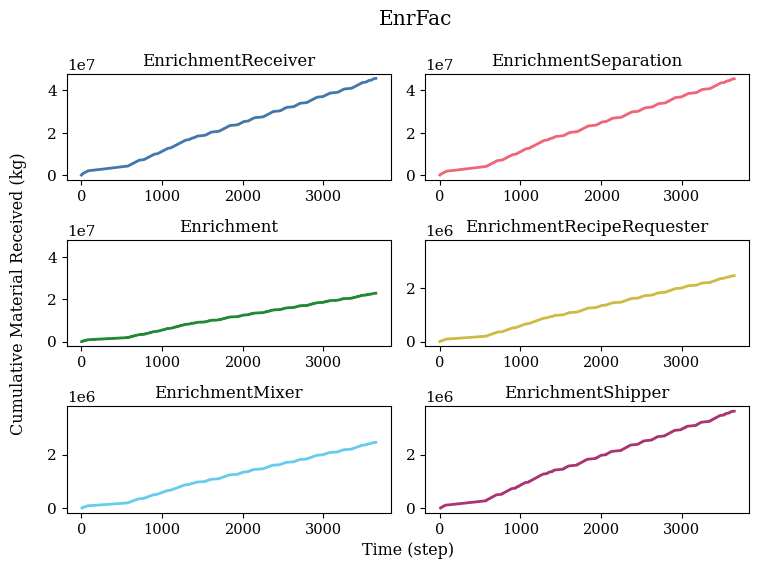

In [13]:
fig = plt.figure(figsize = (8, 6))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

###

ax0 = fig.add_subplot(321)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# plt.xlim(-0.5,16)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))

ax0.step(enr_rec[enr_fac[0]]['Time'],
         enr_rec[enr_fac[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(enr_fac[0])

###

ax1 = fig.add_subplot(322, sharex=ax0, sharey=ax0)
ax1.step(enr_rec[enr_fac[1]]['Time'],
         enr_rec[enr_fac[1]]['CumQuantityReceived'],
         color= palette[1])
ax1.set_title(enr_fac[1])

###

ax2 = fig.add_subplot(323, sharex=ax0, sharey=ax0)
ax2.step(enr_rec[enr_fac[2]]['Time'],
         enr_rec[enr_fac[2]]['CumQuantityReceived'],
         color= palette[2])
ax2.set_title(enr_fac[2])

###

ax3 = fig.add_subplot(324)#, sharex=ax0, sharey=ax0)
ax3.step(enr_rec[enr_fac[3]]['Time'],
         enr_rec[enr_fac[3]]['CumQuantityReceived'],
         color= palette[3])
ax3.set_title(enr_fac[3])

###

ax4 = fig.add_subplot(325, sharex=ax3, sharey=ax3)
ax4.step(enr_rec[enr_fac[4]]['Time'],
         enr_rec[enr_fac[4]]['CumQuantityReceived'],
         color= palette[4])
ax4.set_title(enr_fac[4])

###

ax5 = fig.add_subplot(326, sharex=ax3, sharey=ax3)
ax5.step(enr_rec[enr_fac[5]]['Time'],
         enr_rec[enr_fac[5]]['CumQuantityReceived'],
         color= palette[5])
ax5.set_title(enr_fac[5])

fig.suptitle('EnrFac', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


In [14]:
data['transactions'].loc[data['transactions']['Time'] == 44][['SenderPrototype','ReceiverPrototype','Commodity','Quantity']]

,SenderPrototype,ReceiverPrototype,Commodity,Quantity
1151,HALEUFuelFabSeparation,HALEUFuelFabMixer,HALEU_ff_separated,20.920000
1152,EnrichmentTailsMixer,EnrichmentTailsPackager,DUF6_mixed,440.000000
1155,Enrichment,EnrichmentTailsMixer,DU_separated,297.440000
1156,EnrichmentReceiver,EnrichmentSeparation,natUF6_received,19836.522201
1157,EnrichmentTailsPackager,EnrichmentTailsStorage,DUF6_packaged,440.000000
1158,EnrichmentShipper,FuelFabReceiver,LEUF6,272.105511
1160,FuelFabReceiver,FuelFabSeparation,LEUF6_received,282.259088
1150,EnrichmentSeparation,Enrichment,natU_separated,7538.624120
1161,HALEUFuelFabShipper,ForeignHALEUO2Reciver,HALEUO2_fuel,217.777778
1162,FuelFabMixer,FuelFabShipper,LEUO2_process,164.053333


In [15]:
data['transactions'].loc[data['transactions']['Time'] == 45][['SenderPrototype','ReceiverPrototype','Commodity','Quantity']]

,SenderPrototype,ReceiverPrototype,Commodity,Quantity
1179,EnrichmentReceiver,EnrichmentSeparation,natUF6_received,19848.463666
1178,Enrichment,EnrichmentTailsMixer,DU_separated,297.440000
1181,EnrichmentShipper,FuelFabReceiver,LEUF6,282.259088
1176,Enrichment,EnrichmentRecipeRequester,LEU_enr_separated,1107.039000
1175,EnrichmentTailsMixer,EnrichmentTailsPackager,DUF6_mixed,440.000000
1174,HALEUFuelFabSeparation,HALEUFuelFabMixer,HALEU_ff_separated,246.820000
1173,EnrichmentSeparation,Enrichment,natU_separated,10200.089160
1182,ForeignHALEUF6Shipper,HALEUFuelFabReceiver,HALEUF6,464.673509
1171,FuelFabSeparation,FuelFabMixer,LEU_ff_separated,144.613013
1170,MillShipper,ForeignUOCReceiver,UOC_shipment,2740.000000


In [16]:
data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper'] ['Quantity'].unique()

array([3275.26331361, 1637.6316568 ,  271.99224338, ...,  293.84926464,
        293.8492645 ,  293.84921702])

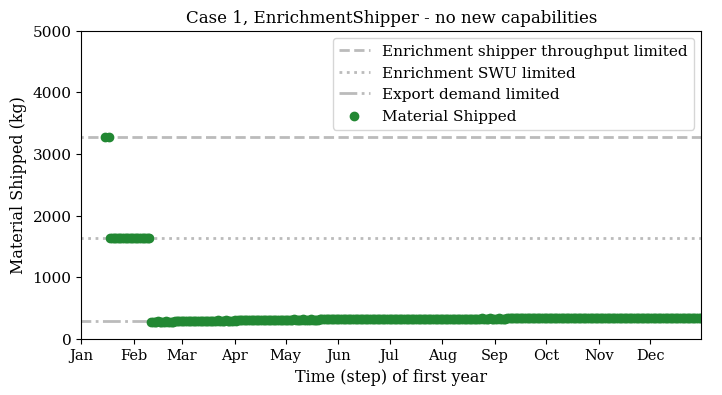

In [17]:
fig = plt.figure(figsize = (8, 4))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step) of first year')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

ax0 = fig.add_subplot(111)

ax0.hlines(y=3274.32,xmin=-5,xmax=3651, colors=palette[-2], linestyles='dashed', label='Enrichment shipper throughput limited', zorder=0)
ax0.hlines(y=1637.63,xmin=-5,xmax=3651, colors=palette[-2], linestyles='dotted', label='Enrichment SWU limited', zorder=0)
ax0.hlines(y=293.84,xmin=-5,xmax=3651, colors=palette[-2], linestyles='dashdot', label='Export demand limited', zorder=0)

ax0.set_xlim([0,364])
ax0.set_ylim([0,5000])
ax0.set_ylabel('Material Shipped (kg)')

ax0.xaxis.set_major_locator(mdates.MonthLocator())
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
# ax0.xaxis.set_minor_locator(mdates.YearLocator(base=1))

ax0.scatter(data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper'] ['Date'],
         data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper'] ['Quantity'],
         color= palette[2],
           label="Material Shipped")
ax0.set_title("Case 1, " + enr_fac[5] + " - no new capabilities")

plt.legend()


plt.savefig('plots/c1_no-behav-enrichment-shipper', transparent=True)

In [18]:
data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper'] ['Date'],

(410     2025-01-15 00:00:00+00:00
 474     2025-01-17 00:00:00+00:00
 456     2025-01-18 00:00:00+00:00
 483     2025-01-19 00:00:00+00:00
 509     2025-01-20 00:00:00+00:00
                    ...           
 84044   2034-12-25 00:00:00+00:00
 84065   2034-12-26 00:00:00+00:00
 84084   2034-12-27 00:00:00+00:00
 84104   2034-12-28 00:00:00+00:00
 84123   2034-12-29 00:00:00+00:00
 Name: Date, Length: 3635, dtype: datetime64[ns, UTC],)

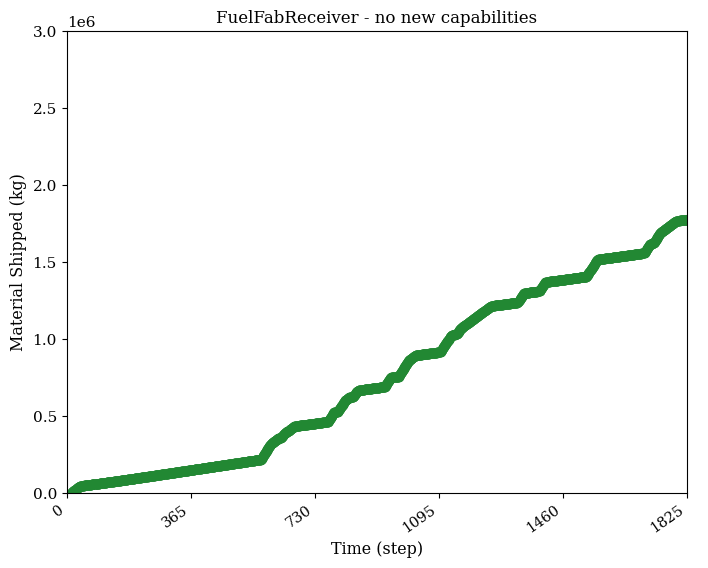

In [19]:
fig = plt.figure(figsize = (8, 6))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
# ax.set_xlabel('Time (step)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

ax0 = fig.add_subplot(111)
ax0.set_xlim([00,1825])
ax0.set_ylim([0,3000000])
ax0.set_ylabel('Material Shipped (kg)')

ax0.scatter(data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper'] ['Time'],
         data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper'] ['Quantity'].cumsum(),
         color= palette[2])
ax0.set_title('FuelFabReceiver - no new capabilities')

ax0.set_xlabel('Time (step)')
ax0.set_xticks(np.arange(0, 1826, 365))
for label in ax0.get_xticklabels(which='major'):
    label.set(rotation=35, horizontalalignment='right')

In [20]:
ffrec_dom=data['transactions'].loc[data['transactions']['ReceiverPrototype'] == 'FuelFabReceiver'].groupby(by=['Time', 'SenderPrototype'])['Quantity'].sum().reset_index()
ffrec_dom

,Time,SenderPrototype,Quantity
0,0,ForeignLEUF6Shipper,10745.000000
1,2,ForeignLEUF6Shipper,10745.000000
2,4,ForeignLEUF6Shipper,10745.000000
3,6,ForeignLEUF6Shipper,10745.000000
4,8,ForeignLEUF6Shipper,10745.000000
...,...,...,...
4068,3645,EnrichmentShipper,291.709140
4069,3646,EnrichmentShipper,295.890863
4070,3647,EnrichmentShipper,293.849265
4071,3648,EnrichmentShipper,293.849264


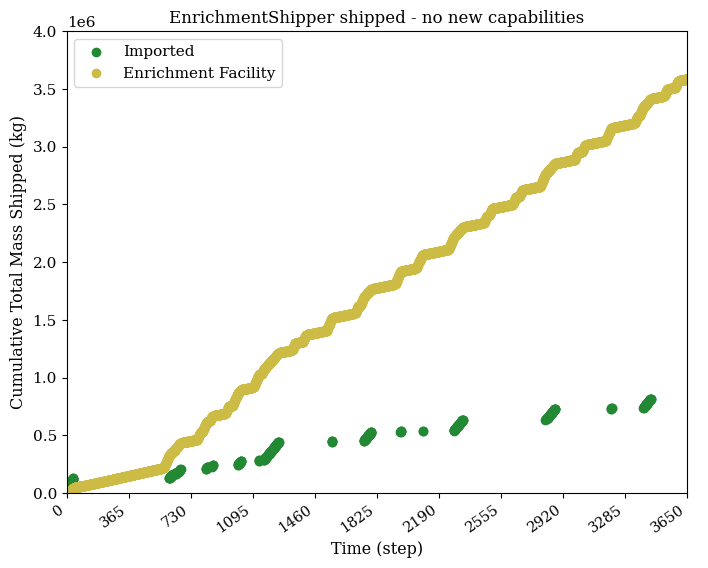

In [21]:
fig = plt.figure(figsize = (8, 6))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)

ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)


ax1 = fig.add_subplot(111)
ax1.set_xlim([00,1825])
ax1.set_ylim([0,4000000])
ax1.set_ylabel('Cumulative Total Mass Shipped (kg)')

ax1.scatter(ffrec_dom.loc[ffrec_dom['SenderPrototype'] == 'ForeignLEUF6Shipper']['Time'],
         ffrec_dom.loc[ffrec_dom['SenderPrototype'] == 'ForeignLEUF6Shipper']['Quantity'].cumsum(),
         color= palette[2],
           label="Imported")
ax1.scatter(ffrec_dom.loc[ffrec_dom['SenderPrototype'] == 'EnrichmentShipper']['Time'],
         ffrec_dom.loc[ffrec_dom['SenderPrototype'] == 'EnrichmentShipper']['Quantity'].cumsum(),
         color= palette[3],
           label="Enrichment Facility")
# ax1.set_title(enr_fac[5])

ax1.set_xlabel('Time (step)')
ax1.set_xticks(np.arange(0, 3655, 365))
for label in ax1.get_xticklabels(which='major'):
    label.set(rotation=35, horizontalalignment='right')

ax1.set_title('EnrichmentShipper shipped - no new capabilities')
ax1.legend()

In [22]:
len(ff_fac)

8

In [23]:
ff_rec = {}
for ag in ff_fac:
    ff_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

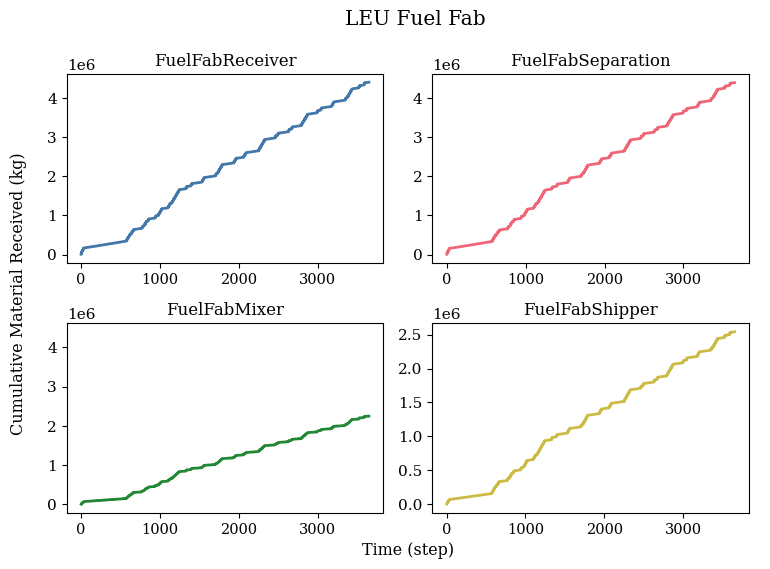

In [24]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

###

ax0 = fig.add_subplot(221)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# plt.xlim(-0.5,16)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))

ax0.step(ff_rec[ff_fac[0]]['Time'],
         ff_rec[ff_fac[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(ff_fac[0])

###

ax1 = fig.add_subplot(222, sharex=ax0, sharey=ax0)
ax1.step(ff_rec[ff_fac[1]]['Time'],
         ff_rec[ff_fac[1]]['CumQuantityReceived'],
         color= palette[1])
ax1.set_title(ff_fac[1])

###

ax2 = fig.add_subplot(223, sharex=ax0, sharey=ax0)
ax2.step(ff_rec[ff_fac[2]]['Time'],
         ff_rec[ff_fac[2]]['CumQuantityReceived'],
         color= palette[2])
ax2.set_title(ff_fac[2])

###

ax3 = fig.add_subplot(224)#, sharex=ax0, sharey=ax0)
ax3.step(ff_rec[ff_fac[3]]['Time'],
         ff_rec[ff_fac[3]]['CumQuantityReceived'],
         color= palette[3])
ax3.set_title(ff_fac[3])

###


fig.suptitle('LEU Fuel Fab', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


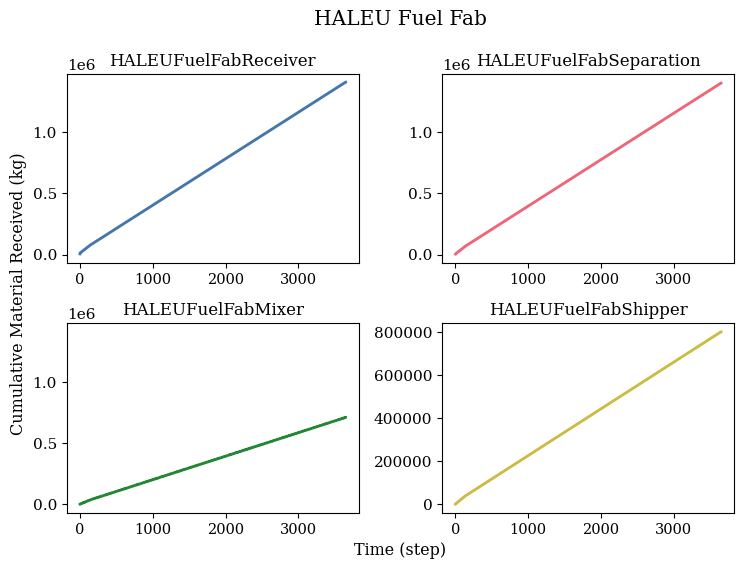

In [25]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(221)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# plt.xlim(-0.5,16)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(4,6))

ax0.step(ff_rec[ff_fac[4]]['Time'],
         ff_rec[ff_fac[4]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(ff_fac[4])

###

ax1 = fig.add_subplot(222, sharex=ax0, sharey=ax0)
ax1.step(ff_rec[ff_fac[5]]['Time'],
         ff_rec[ff_fac[5]]['CumQuantityReceived'],
         color= palette[1])
ax1.set_title(ff_fac[5])

###

ax2 = fig.add_subplot(223, sharex=ax0, sharey=ax0)
ax2.step(ff_rec[ff_fac[6]]['Time'],
         ff_rec[ff_fac[6]]['CumQuantityReceived'],
         color= palette[2])
ax2.set_title(ff_fac[6])

###

ax3 = fig.add_subplot(224)#, sharex=ax0, sharey=ax0)
ax3.step(ff_rec[ff_fac[7]]['Time'],
         ff_rec[ff_fac[7]]['CumQuantityReceived'],
         color= palette[3])
ax3.set_title(ff_fac[7])
# ax3.ticklabel_format(axis='y', style='sci', scilimits=(-4,5))

###

fig.suptitle('HALEU Fuel Fab', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


In [26]:
x=data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper']

(array([2.609e+03, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 4.110e+02,
        0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 1.600e+01,
        2.000e+00, 1.000e+00, 8.000e+00, 8.500e+01, 3.430e+02, 3.800e+01,
        1.300e+01, 4.000e+00, 6.000e+00, 1.600e+01, 1.600e+01, 3.400e+01,
        1.400e+01, 5.000e+00]),
 array([ 271.99224338,  350.21750538,  428.44276738,  506.66802938,
         584.89329138,  663.11855338,  741.34381538,  819.56907738,
         897.79433937,  976.01960137, 1054.24486337, 1132.47012537,
        1210.69538737, 1288.92064937, 1367.14591137, 1445.37117337,
        1523.59643537, 1601.82169737, 1680.04695936, 1758.27222136,
        1836.49748336, 1914.72274536

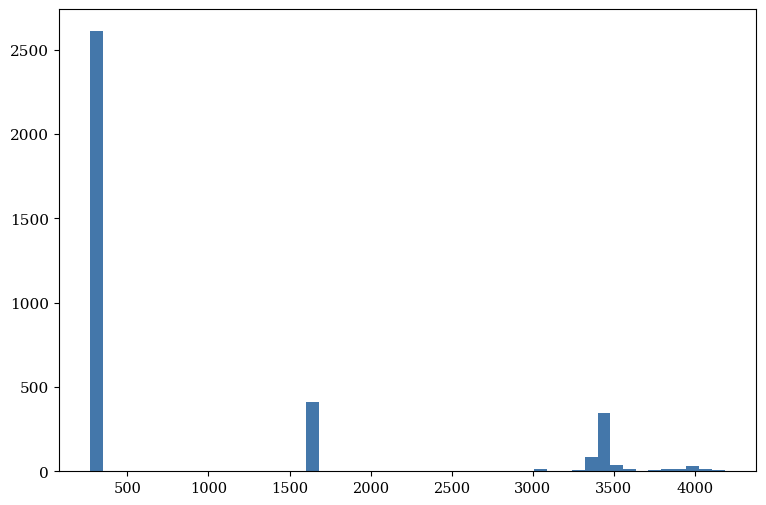

In [27]:
#x.loc[(x['Time'] < 630) & (x['Time'] > 570)]['Quantity'].unique()
plt.hist(x['Quantity'],50)

Text(0.5, 1.0, 'EnrichmentShipper')

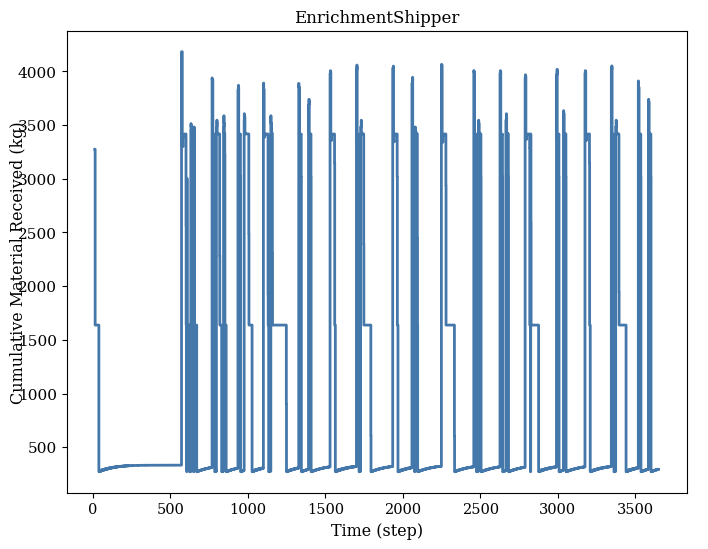

In [28]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(111)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# ax0.axis(xmin=570,
#          xmax=630)
# ax0.axis(ymin=0,
#          ymax=1000)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
#ax0.ticklabel_format(axis='y', style='sci')#, scilimits=(-4,4))

ax0.step(data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper']['Time'],
         data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper']['Quantity'],
         color= palette[0])
ax0.set_title('EnrichmentShipper')

In [29]:
len(rx_A)

5

In [30]:
rxA_rec = {}
for ag in rx_A:
    rxA_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

rxB_rec = {}
for ag in rx_B:
    rxB_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

rxC_rec = {}
for ag in rx_C:
    rxC_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

rxD_rec = {}
for ag in rx_D:
    rxD_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

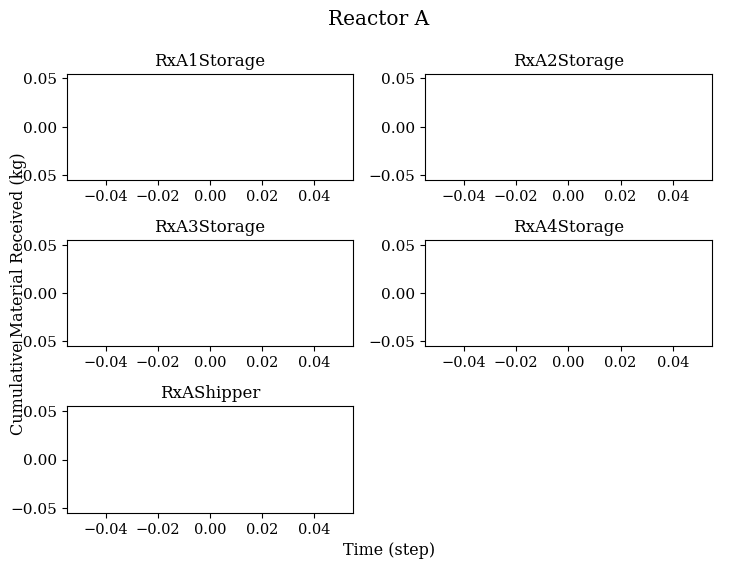

In [31]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(321)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# plt.xlim(-0.5,16)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(rxA_rec[rx_A[0]]['Time'],
         rxA_rec[rx_A[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(rx_A[0])

###

ax1 = fig.add_subplot(322, sharex=ax0, sharey=ax0)
ax1.step(rxA_rec[rx_A[1]]['Time'],
         rxA_rec[rx_A[1]]['CumQuantityReceived'],
         color= palette[1])
ax1.set_title(rx_A[1])

###

ax2 = fig.add_subplot(323, sharex=ax0, sharey=ax0)
ax2.step(rxA_rec[rx_A[2]]['Time'],
         rxA_rec[rx_A[2]]['CumQuantityReceived'],
         color= palette[2])
ax2.set_title(rx_A[2])

###

ax3 = fig.add_subplot(324, sharex=ax0, sharey=ax0)
ax3.step(rxA_rec[rx_A[3]]['Time'],
         rxA_rec[rx_A[3]]['CumQuantityReceived'],
         color= palette[3])
ax3.set_title(rx_A[3])

###

ax4 = fig.add_subplot(325, sharex=ax0, sharey=ax0)
ax4.step(rxA_rec[rx_A[4]]['Time'],
         rxA_rec[rx_A[4]]['CumQuantityReceived'],
         color= palette[3])
ax4.set_title(rx_A[4])

###

fig.suptitle('Reactor A', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


In [32]:
len(rx_B)

8

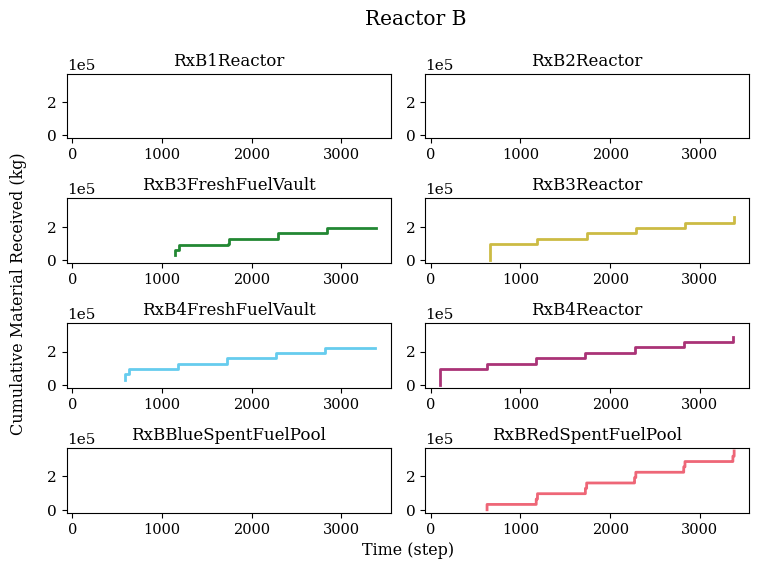

In [33]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(421)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# plt.xlim(-0.5,1100)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(rxB_rec[rx_B[0]]['Time'],
         rxB_rec[rx_B[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(rx_B[0])

###

ax1 = fig.add_subplot(422, sharex=ax0, sharey=ax0)
ax1.step(rxB_rec[rx_B[1]]['Time'],
         rxB_rec[rx_B[1]]['CumQuantityReceived'],
         color= palette[1])
ax1.set_title(rx_B[1])

###

ax2 = fig.add_subplot(423, sharex=ax0, sharey=ax0)
ax2.step(rxB_rec[rx_B[2]]['Time'],
         rxB_rec[rx_B[2]]['CumQuantityReceived'],
         color= palette[2])
ax2.set_title(rx_B[2])

###

ax3 = fig.add_subplot(424, sharex=ax0, sharey=ax0)
ax3.step(rxB_rec[rx_B[3]]['Time'],
         rxB_rec[rx_B[3]]['CumQuantityReceived'],
         color= palette[3])
ax3.set_title(rx_B[3])

###

ax4 = fig.add_subplot(425, sharex=ax0, sharey=ax0)
ax4.step(rxB_rec[rx_B[4]]['Time'],
         rxB_rec[rx_B[4]]['CumQuantityReceived'],
         color= palette[4])
ax4.set_title(rx_B[4])

###

ax5 = fig.add_subplot(426, sharex=ax0, sharey=ax0)
ax5.step(rxB_rec[rx_B[5]]['Time'],
         rxB_rec[rx_B[5]]['CumQuantityReceived'],
         color= palette[5])
ax5.set_title(rx_B[5])

###

ax6 = fig.add_subplot(427, sharex=ax0, sharey=ax0)
ax6.step(rxB_rec[rx_B[6]]['Time'],
         rxB_rec[rx_B[6]]['CumQuantityReceived'],
         color= palette[6])
ax6.set_title(rx_B[6])

###

ax7 = fig.add_subplot(428, sharex=ax0, sharey=ax0)
ax7.step(rxB_rec[rx_B[7]]['Time'],
         rxB_rec[rx_B[7]]['CumQuantityReceived'],
         color= palette[1])
ax7.set_title(rx_B[7])

###

fig.suptitle('Reactor B', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


In [34]:
len(rx_C)

11

In [35]:
print(rx_C)

['RxC1FreshFuelVault', 'RxC1Reactor', 'RxC2FreshFuelVault', 'RxC2Reactor', 'RxC3FreshFuelVault', 'RxC3Reactor', 'RxC4FreshFuelVault', 'RxC4Reactor', 'RxCBlueSpentFuelPool', 'RxCRedSpentFuelPool', 'RxCShipper']


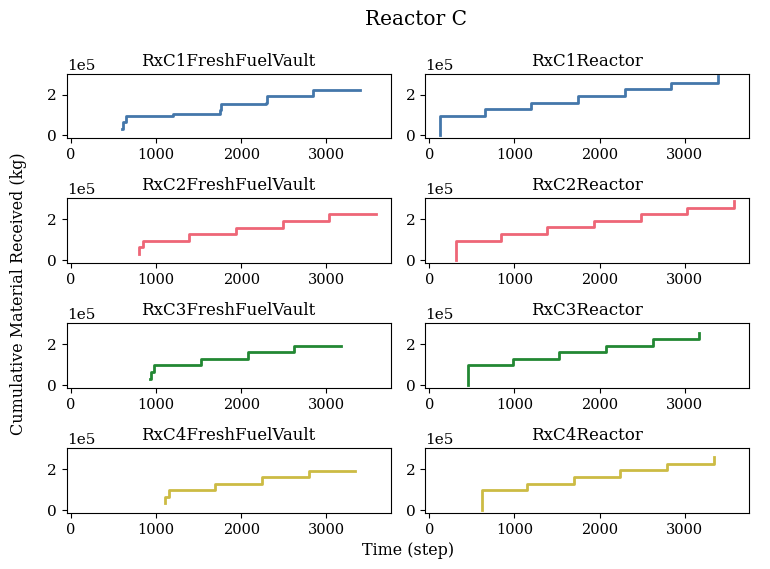

In [36]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(421)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
#plt.xlim(-0.5,1100)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(rxC_rec[rx_C[0]]['Time'],
         rxC_rec[rx_C[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(rx_C[0])

###

ax1 = fig.add_subplot(422, sharex=ax0, sharey=ax0)
ax1.step(rxC_rec[rx_C[1]]['Time'],
         rxC_rec[rx_C[1]]['CumQuantityReceived'],
         color= palette[0])
ax1.set_title(rx_C[1])

###

ax2 = fig.add_subplot(423, sharex=ax0, sharey=ax0)
ax2.step(rxC_rec[rx_C[2]]['Time'],
         rxC_rec[rx_C[2]]['CumQuantityReceived'],
         color= palette[1])
ax2.set_title(rx_C[2])

###

ax3 = fig.add_subplot(424, sharex=ax0, sharey=ax0)
ax3.step(rxC_rec[rx_C[3]]['Time'],
         rxC_rec[rx_C[3]]['CumQuantityReceived'],
         color= palette[1])
ax3.set_title(rx_C[3])

###

ax4 = fig.add_subplot(425, sharex=ax0, sharey=ax0)
ax4.step(rxC_rec[rx_C[4]]['Time'],
         rxC_rec[rx_C[4]]['CumQuantityReceived'],
         color= palette[2])
ax4.set_title(rx_C[4])

###

ax5 = fig.add_subplot(426, sharex=ax0, sharey=ax0)
ax5.step(rxC_rec[rx_C[5]]['Time'],
         rxC_rec[rx_C[5]]['CumQuantityReceived'],
         color= palette[2])
ax5.set_title(rx_C[5])

###

ax6 = fig.add_subplot(427, sharex=ax0, sharey=ax0)
ax6.step(rxC_rec[rx_C[6]]['Time'],
         rxC_rec[rx_C[6]]['CumQuantityReceived'],
         color= palette[3])
ax6.set_title(rx_C[6])

###

ax7 = fig.add_subplot(428, sharex=ax0, sharey=ax0)
ax7.step(rxC_rec[rx_C[7]]['Time'],
         rxC_rec[rx_C[7]]['CumQuantityReceived'],
         color= palette[3])
ax7.set_title(rx_C[7])

###

fig.suptitle('Reactor C', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


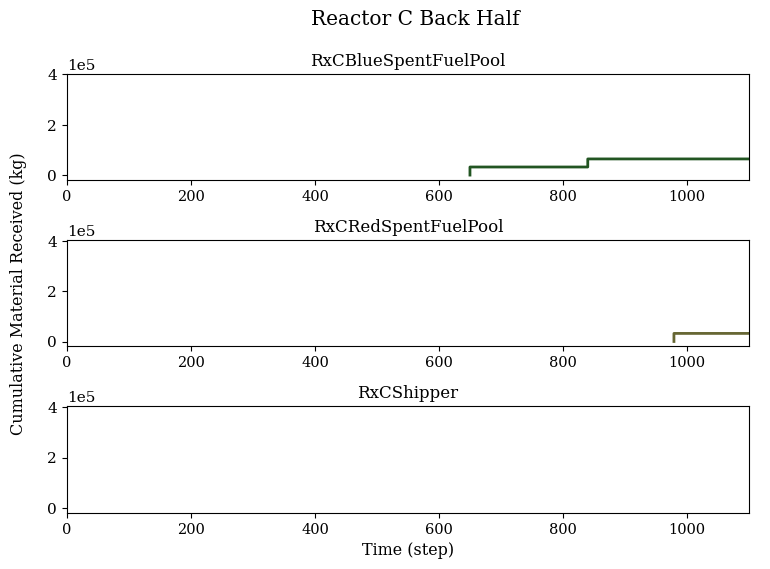

In [37]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(311)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
plt.xlim(-0.5,1100)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(rxC_rec[rx_C[8]]['Time'],
         rxC_rec[rx_C[8]]['CumQuantityReceived'],
         color= palette[8])
ax0.set_title(rx_C[8])

###

ax1 = fig.add_subplot(312, sharex=ax0, sharey=ax0)
ax1.step(rxC_rec[rx_C[9]]['Time'],
         rxC_rec[rx_C[9]]['CumQuantityReceived'],
         color= palette[9])
ax1.set_title(rx_C[9])

###

ax2 = fig.add_subplot(313, sharex=ax0, sharey=ax0)
ax2.step(rxC_rec[rx_C[10]]['Time'],
         rxC_rec[rx_C[10]]['CumQuantityReceived'],
         color= palette[10])
ax2.set_title(rx_C[10])

###

fig.suptitle('Reactor C Back Half', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


In [38]:
len(rx_D)

11

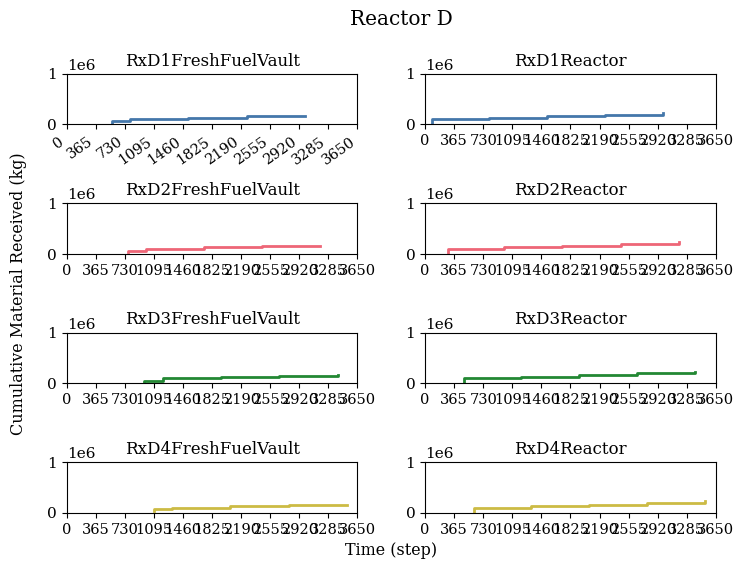

In [39]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(421)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
ax0.set_xlim(-0.5,1100)
ax0.set_ylim(0,1000000)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))
ax0.set_xticks(np.arange(0, 3655, 365))
for label in ax0.get_xticklabels(which='major'):
    label.set(rotation=35, horizontalalignment='right')

ax0.step(rxD_rec[rx_D[0]]['Time'],
         rxD_rec[rx_D[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(rx_D[0])

###

ax1 = fig.add_subplot(422, sharex=ax0, sharey=ax0)
ax1.step(rxD_rec[rx_D[1]]['Time'],
         rxD_rec[rx_D[1]]['CumQuantityReceived'],
         color= palette[0])
ax1.set_title(rx_D[1])

###

ax2 = fig.add_subplot(423, sharex=ax0, sharey=ax0)
ax2.step(rxD_rec[rx_D[2]]['Time'],
         rxD_rec[rx_D[2]]['CumQuantityReceived'],
         color= palette[1])
ax2.set_title(rx_D[2])

###

ax3 = fig.add_subplot(424, sharex=ax0, sharey=ax0)
ax3.step(rxD_rec[rx_D[3]]['Time'],
         rxD_rec[rx_D[3]]['CumQuantityReceived'],
         color= palette[1])
ax3.set_title(rx_D[3])

###

ax4 = fig.add_subplot(425, sharex=ax0, sharey=ax0)
ax4.step(rxD_rec[rx_D[4]]['Time'],
         rxD_rec[rx_D[4]]['CumQuantityReceived'],
         color= palette[2])
ax4.set_title(rx_D[4])

###

ax5 = fig.add_subplot(426, sharex=ax0, sharey=ax0)
ax5.step(rxD_rec[rx_D[5]]['Time'],
         rxD_rec[rx_D[5]]['CumQuantityReceived'],
         color= palette[2])
ax5.set_title(rx_D[5])

###

ax6 = fig.add_subplot(427, sharex=ax0, sharey=ax0)
ax6.step(rxD_rec[rx_D[6]]['Time'],
         rxD_rec[rx_D[6]]['CumQuantityReceived'],
         color= palette[3])
ax6.set_title(rx_D[6])

###

ax7 = fig.add_subplot(428, sharex=ax0, sharey=ax0)
ax7.step(rxD_rec[rx_D[7]]['Time'],
         rxD_rec[rx_D[7]]['CumQuantityReceived'],
         color= palette[3])
ax7.set_title(rx_D[7])

###

fig.suptitle('Reactor D', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


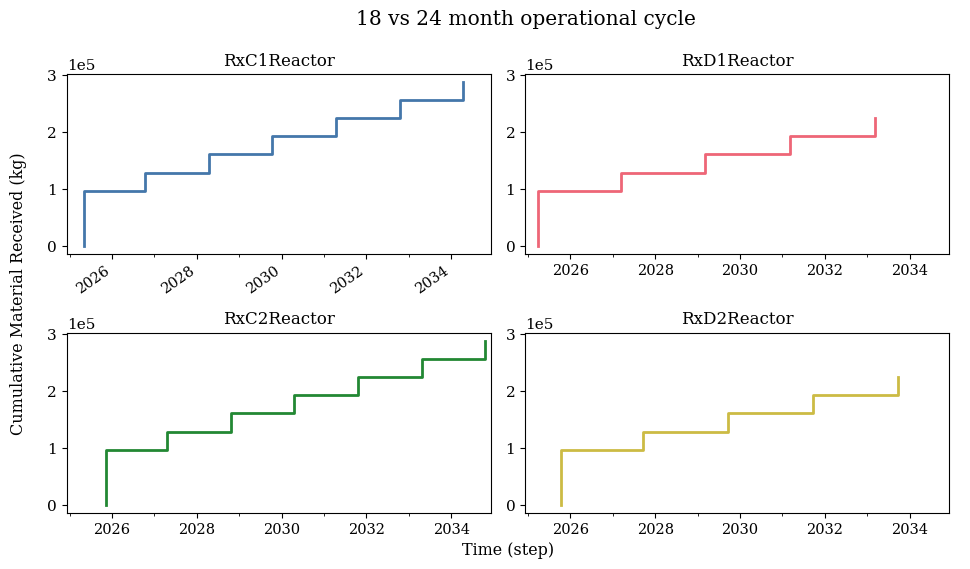

In [40]:
fig = plt.figure(figsize = (10, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(221)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
ax0.set_xlim(-0.5,1186)
# plt.ylim(0,20)
ax0.set_xticks(np.arange(-25, 3655, 365))
for label in ax0.get_xticklabels(which='major'):
    label.set(rotation=35, horizontalalignment='right')

ax0.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax0.xaxis.set_minor_locator(mdates.YearLocator(base=1))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(rxC_rec[rx_C[1]]['Date'],
         rxC_rec[rx_C[1]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(rx_C[1])

###

ax1 = fig.add_subplot(222, sharex=ax0, sharey=ax0)
ax1.step(rxD_rec[rx_D[1]]['Date'],
         rxD_rec[rx_D[1]]['CumQuantityReceived'],
         color= palette[1])
ax1.set_title(rx_D[1])

###

ax2 = fig.add_subplot(223, sharex=ax0, sharey=ax0)
ax2.step(rxC_rec[rx_C[3]]['Date'],
         rxC_rec[rx_C[3]]['CumQuantityReceived'],
         color= palette[2])
ax2.set_title(rx_C[3])

###

ax3 = fig.add_subplot(224, sharex=ax0, sharey=ax0)
ax3.step(rxD_rec[rx_D[3]]['Date'],
         rxD_rec[rx_D[3]]['CumQuantityReceived'],
         color= palette[3])
ax3.set_title(rx_D[3])

###

fig.suptitle('18 vs 24 month operational cycle', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


Text(0.5, 1.0, 'RxD1FreshFuelVault')

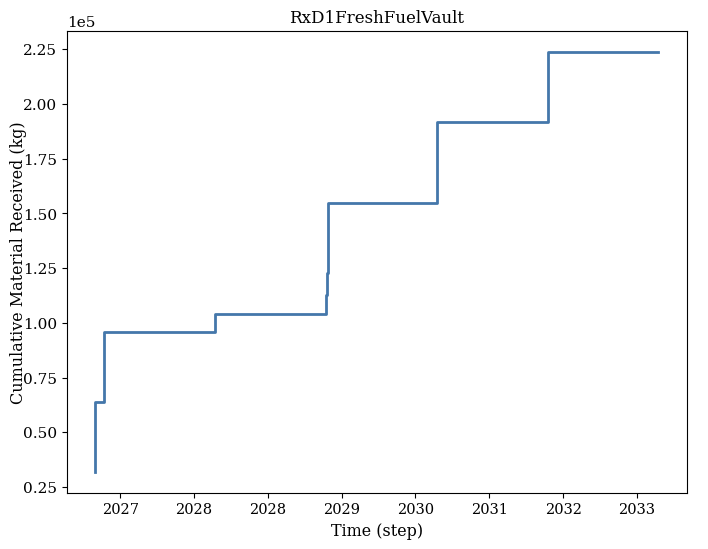

In [41]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(111)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
#plt.xlim(-0.5,1100)
# plt.ylim(0,20)
ax0.set_xticks(np.arange(0, 3650, 365))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(mdates.num2date(rxC_rec[rx_C[0]]['Time']),
         rxC_rec[rx_C[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(rx_D[0])
